In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

C:\Users\hp\OneDrive\Documents\Nouveau dossier\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\hp\OneDrive\Documents\Nouveau dossier\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [10]:
zip_path = "archive.zip"
extract_path = "archive"

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['.ipynb_checkpoints', 'lettuce_dataset.csv', 'lettuce_dataset_updated.csv', 'unseen_data.csv', 'Untitled.ipynb']


In [11]:
file_path = os.path.join(
    extract_path,
    "lettuce_dataset_updated.csv"
)

df = pd.read_csv(file_path, encoding="latin1")

print("Initial Shape :", df.shape)
df.head()

Initial Shape : (3169, 9)


,Plant_ID,Date,Temperature (°C),Humidity (%),TDS Value (ppm),pH Level,Growth Days,Temperature (F),Humidity
0,1,8/3/2023,33.4,53,582,6.4,1,92.12,0.53
1,1,8/4/2023,33.5,53,451,6.1,2,92.30,0.53
2,1,8/5/2023,33.4,59,678,6.4,3,92.12,0.59
3,1,8/6/2023,33.4,68,420,6.4,4,92.12,0.68
4,1,8/7/2023,33.4,74,637,6.5,5,92.12,0.74


In [12]:
df = df.drop_duplicates()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = pd.to_numeric(col, errors="coerce")

df.fillna(df.mean(numeric_only=True), inplace=True)

for col in ["Plant_ID", "Date"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

print("Shape after cleaning :", df.shape)

Shape after cleaning : (3169, 7)


In [13]:
numeric_df = df.select_dtypes(include=np.number)

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)

IQR = Q3 - Q1

mask = ~(
    (
        (numeric_df < (Q1 - 1.5 * IQR)) |
        (numeric_df > (Q3 + 1.5 * IQR))
    ).any(axis=1)
)

df = df[mask]

print("Shape after outliers :", df.shape)

Shape after outliers : (3169, 7)


In [14]:
target = "Growth Days"

X = df.drop(columns=[target])
y = df[target]

X = X.select_dtypes(include=np.number)

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (3169, 6)
Target Shape : (3169,)


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Normalization DONE")

Normalization DONE


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape :", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape : (2535, 6)
Test Shape : (634, 6)


In [17]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("LINEAR REGRESSION")
print(mae_lr, rmse_lr, r2_lr)

LINEAR REGRESSION
10.813422208365221 13.03392250207475 0.016829541854987307


In [18]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("DECISION TREE")
print(mae_dt, rmse_dt, r2_dt)

DECISION TREE
5.698738170347003 10.693832061709116 0.3381717958617817


In [19]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RANDOM FOREST")
print(mae_rf, rmse_rf, r2_rf)

RANDOM FOREST
4.956080704521556 8.277449719411587 0.6034740133067414


In [31]:
ann_model = Sequential([

    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)

])

ann_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
159/159 [==============================] - 5s 13ms/step - loss: 307.3338 - mae: 14.3401 - val_loss: 199.0189 - val_mae: 11.8107
Epoch 2/100
159/159 [==============================] - 2s 11ms/step - loss: 189.1569 - mae: 11.7584 - val_loss: 195.2326 - val_mae: 11.7188
Epoch 3/100
159/159 [==============================] - 2s 12ms/step - loss: 184.7702 - mae: 11.7045 - val_loss: 190.0258 - val_mae: 11.6024
Epoch 4/100
159/159 [==============================] - 2s 11ms/step - loss: 179.8845 - mae: 11.5469 - val_loss: 183.7258 - val_mae: 11.5424
Epoch 5/100
159/159 [==============================] - 2s 10ms/step - loss: 176.2352 - mae: 11.4685 - val_loss: 178.8514 - val_mae: 11.4088
Epoch 6/100
159/159 [==============================] - 2s 11ms/step - loss: 170.8220 - mae: 11.3510 - val_loss: 172.5029 - val_mae: 11.1890
Epoch 7/100
159/159 [==============================] - 2s 12ms/step - loss: 165.5150 - mae: 11.1912 - val_loss: 166.0442 - val_mae: 11.0887
Epoch 8/100
159/159 

In [32]:
y_pred_ann = ann_model.predict(X_test).flatten()

mae_ann = mean_absolute_error(y_test, y_pred_ann)
rmse_ann = np.sqrt(mean_squared_error(y_test, y_pred_ann))
r2_ann = r2_score(y_test, y_pred_ann)

print("ANN RESULTS")
print(mae_ann, rmse_ann, r2_ann)

20/20 [==============================] - 0s 6ms/step
ANN RESULTS
9.218345716172589 10.903075493803664 0.3120187692349118


In [33]:
results = pd.DataFrame({



    "Model": [

        "Linear Regression",

        "Decision Tree",

        "Random Forest",

        "ANN"

    ],



    "MAE": [

        mae_lr,

        mae_dt,

        mae_rf,

        mae_ann

    ],



    "RMSE": [

        rmse_lr,

        rmse_dt,

        rmse_rf,

        rmse_ann

    ],



    "R2": [

        r2_lr,

        r2_dt,

        r2_rf,

        r2_ann

    ]

})



results

,Model,MAE,RMSE,R2
0,Linear Regression,10.813422,13.033923,0.016830
1,Decision Tree,5.698738,10.693832,0.338172
2,Random Forest,4.956081,8.277450,0.603474
3,ANN,9.218346,10.903075,0.312019


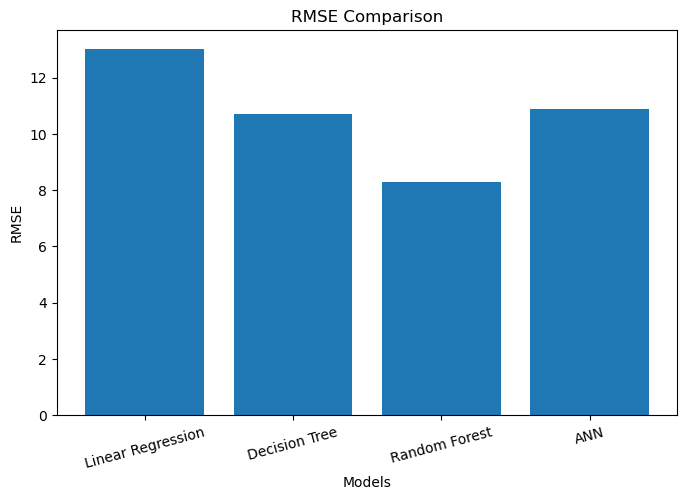

In [34]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

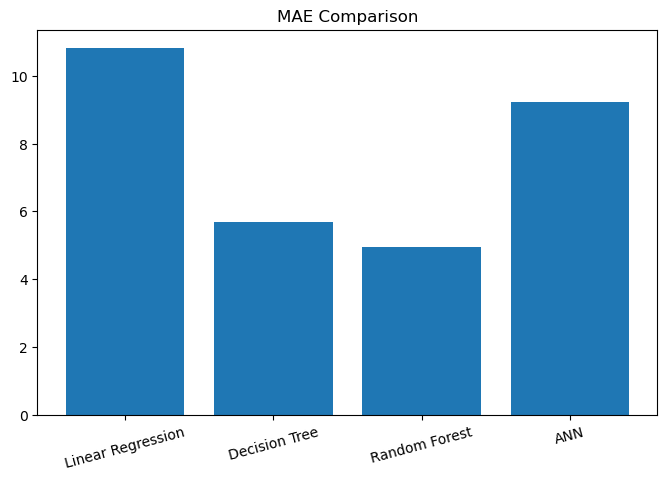

In [35]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["MAE"])
plt.title("MAE Comparison")
plt.xticks(rotation=15)
plt.show()

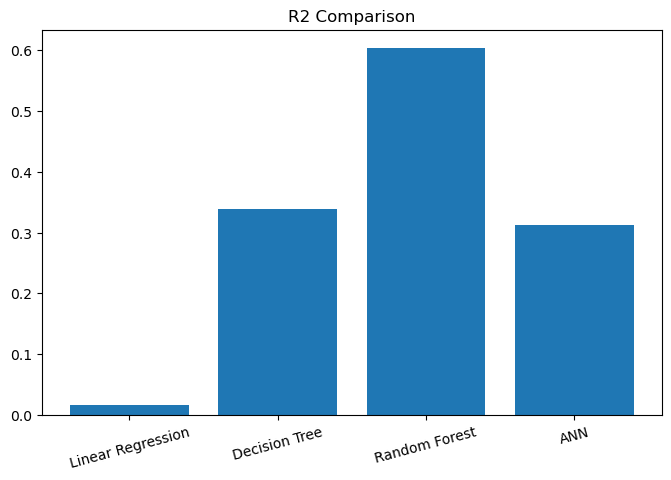

In [36]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R2"])
plt.title("R2 Comparison")
plt.xticks(rotation=15)
plt.show()

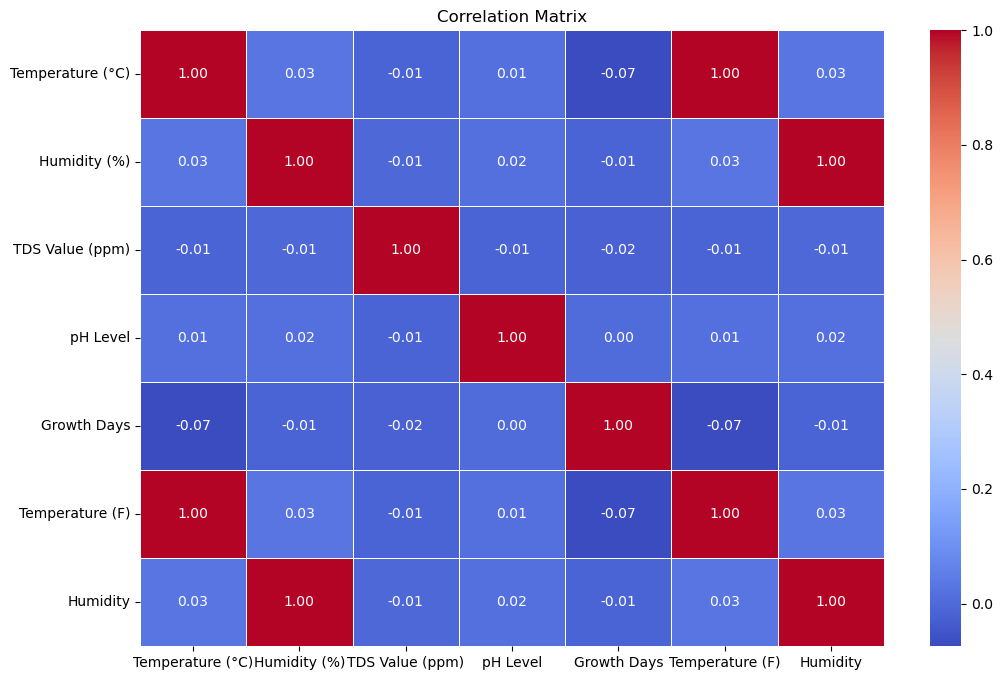

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

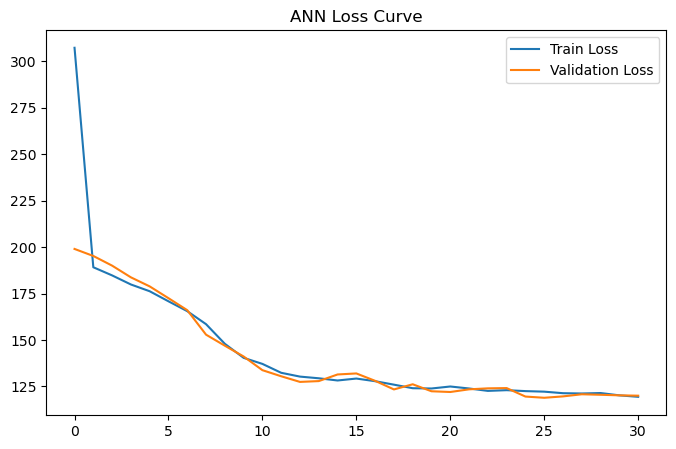

In [38]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.legend()
plt.title("ANN Loss Curve")
plt.show()

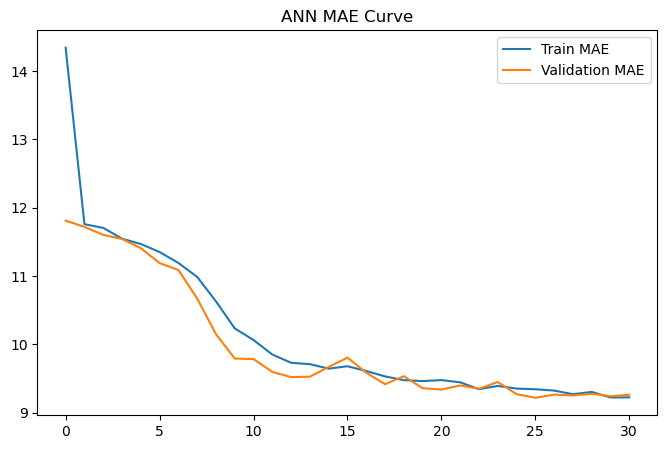

In [39]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.legend()
plt.title("ANN MAE Curve")
plt.show()

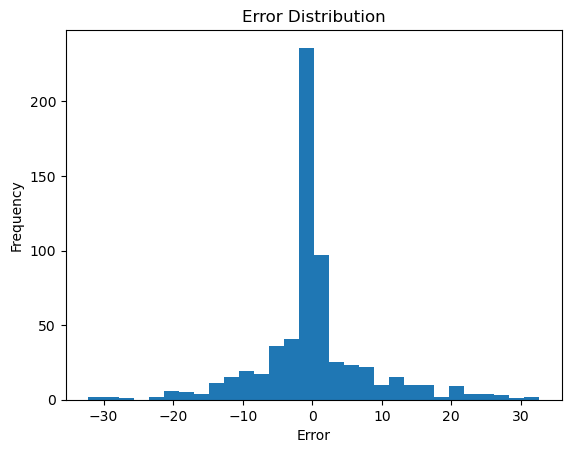

In [40]:
errors = y_test - y_pred_rf

errors = np.array(errors)
errors = errors[np.isfinite(errors)]  # plus propre que nan check

plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

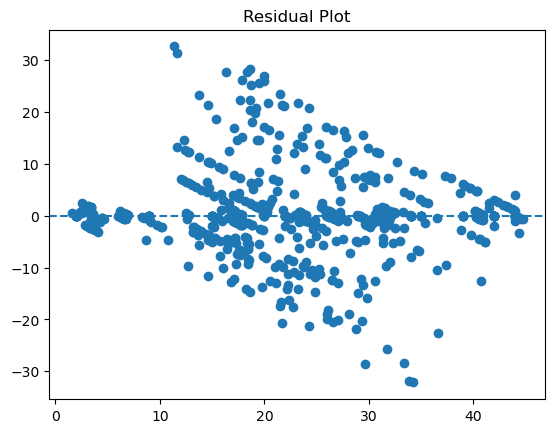

In [41]:
residuals = y_test - y_pred_rf

plt.scatter(y_pred_rf, residuals)
plt.axhline(0, linestyle='--')

plt.title("Residual Plot")
plt.show()

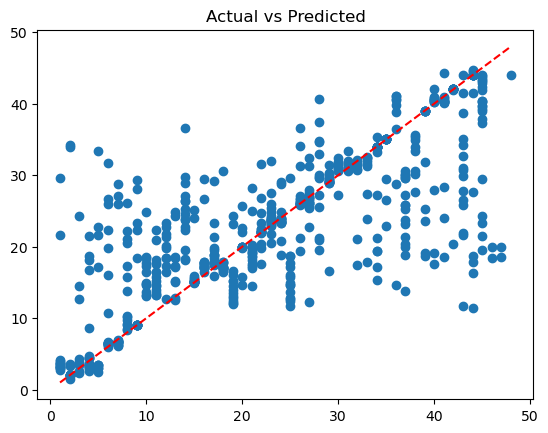

In [42]:
plt.scatter(y_test, y_pred_rf)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Actual vs Predicted")
plt.show()

In [43]:
ann_model.save("plant_model.keras")

print("DONE")

DONE
